**Project Overview:**

This machine learning project examines a cohort of NHL players from the 2016–2017 season and aims to use their statistical profiles to predict their salaries. The two datasets used include various data types: nominal (e.g., player position), ordinal (e.g., draft rank), discrete (e.g., total goals), and continuous (e.g., on-ice Corsi For %). Players on NHL Entry-Level Contracts were excluded, as these contracts—standardized at an average annual salary of $925,000—do not reflect a player’s performance, draft position, or market value. This important filtering step was performed by Brad Klassen, whose preprocessing work ensured the data would be more appropriate for machine learning applications.

Additional data cleaning was performed in Excel to remove duplicate columns shared across the two datasets. The salary dataset from Kaggle included fields such as nationality and team, which were excluded as they were not expected to meaningfully impact contract value. However, attributes like player handedness were retained due to their relevance—right-handed defensemen, for instance, are often valued differently. Core performance statistics like goals, assists, and points were preserved, along with advanced metrics from MoneyPuck. Some advanced stats were omitted due to unclear labeling and the absence of a data dictionary. The final six columns in the MoneyPuck dataset, all of which contained only zeros, were removed during preprocessing. Lastly, a little more cleaning was completed in Python in order to remove duplicate columns that had been missed earlier on.

**Data Overview**

In [1]:
import sys

assert sys.version_info >= (3, 7)

In [2]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from xgboost import plot_importance
import lightgbm as lgb
from sklearn.neural_network import MLPRegressor
from tabulate import tabulate
from sklearn.feature_selection import SelectKBest, f_regression

In [4]:
df1 = pd.read_csv("NHL_Salaries_ELC_Removed_Edited.csv")

In [5]:
df2 = pd.read_csv("2016_2017_stats_edited.csv")

In [6]:
#Created a new column for 'name' that would match the format of the name column in the joining data frame

df1['name'] = df1['First Name'] + ' ' + df1['Last Name']
df1 = df1.drop(columns=['First Name', 'Last Name'])

In [7]:
df1.head()

,Salary,Ht,Wt,Hand,Position,GP,G,A,PTS,+/-,PIM,name
0,14000000,75,224,L,C,76,12,40,52,-10,28,Anze Kopitar
1,13800000,71,177,L,RW/C,82,34,55,89,11,32,Patrick Kane
2,13800000,74,201,L,C,72,21,37,58,7,35,Jonathan Toews
3,12000000,76,232,R,D,78,17,25,42,20,38,Shea Weber
4,11000000,73,210,L,C/LW/RW,72,20,35,55,-1,10,Ryan O'Reilly


In [8]:
df = pd.merge(df1, df2, on='name', how='inner')

**Exploratory Data Analysis**

In [9]:
df.head()

,Salary,Ht,Wt,Hand,Position,GP,G,A,PTS,+/-,...,OnIce_A_xGoalsFromxReboundsOfShots,OnIce_A_xGoalsFromActualReboundsOfShots,OnIce_A_reboundxGoals,OnIce_A_xGoals_with_earned_rebounds,OnIce_A_xGoals_with_earned_rebounds_scoreAdjusted,OnIce_A_xGoals_with_earned_rebounds_scoreFlurryAdjusted,OffIce_F_xGoals,OffIce_A_xGoals,OffIce_F_shotAttempts,OffIce_A_shotAttempts
0,14000000,75,224,L,C,76,12,40,52,-10,...,10.49,11.74,11.74,69.95,70.56,69.02,130.06,121.13,2946,2530
1,13800000,71,177,L,RW/C,82,34,55,89,11,...,10.92,19.19,19.47,68.68,68.60,67.45,128.51,152.58,2692,3248
2,13800000,74,201,L,C,72,21,37,58,7,...,10.93,19.25,20.62,68.71,68.51,66.86,121.47,124.95,2581,2771
3,12000000,76,232,R,D,78,17,25,42,20,...,14.36,12.20,12.56,87.28,87.44,85.03,123.23,120.58,2708,2519
4,11000000,73,210,L,C/LW/RW,72,20,35,55,-1,...,13.63,16.31,16.86,82.05,82.58,80.63,112.16,139.90,2459,2959


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 765 entries, 0 to 764
Columns: 153 entries, Salary to OffIce_A_shotAttempts
dtypes: float64(62), int64(88), object(3)
memory usage: 914.5+ KB


In [11]:
print(df.isnull().values.any())

False


In [12]:
df.describe()

,Salary,Ht,Wt,GP,G,A,PTS,+/-,PIM,icetime,...,OnIce_A_xGoalsFromxReboundsOfShots,OnIce_A_xGoalsFromActualReboundsOfShots,OnIce_A_reboundxGoals,OnIce_A_xGoals_with_earned_rebounds,OnIce_A_xGoals_with_earned_rebounds_scoreAdjusted,OnIce_A_xGoals_with_earned_rebounds_scoreFlurryAdjusted,OffIce_F_xGoals,OffIce_A_xGoals,OffIce_F_shotAttempts,OffIce_A_shotAttempts
count,7.650000e+02,765.000000,765.000000,765.000000,765.000000,765.000000,765.000000,765.000000,765.000000,765.000000,...,765.000000,765.000000,765.000000,765.000000,765.000000,765.000000,765.000000,765.000000,765.000000,765.000000
mean,2.487960e+06,73.073203,201.700654,52.032680,7.785621,13.083660,20.869281,-0.219608,26.031373,51354.011765,...,6.220026,6.798824,7.000392,37.722575,37.809569,37.007503,105.243242,106.038484,2116.947712,2133.654902
std,2.373249e+06,2.118202,14.710845,28.580102,8.551112,12.614431,19.801070,10.130245,24.049231,34431.895964,...,4.386195,5.125856,5.272599,26.767792,26.831772,26.195848,57.063123,57.167159,1139.171674,1150.398442
min,5.750000e+05,66.000000,157.000000,1.000000,0.000000,0.000000,0.000000,-34.000000,0.000000,237.000000,...,0.010000,0.000000,0.000000,0.020000,0.020000,0.020000,1.270000,0.790000,30.000000,28.000000
25%,7.250000e+05,72.000000,191.000000,26.000000,1.000000,2.000000,4.000000,-5.000000,8.000000,18688.000000,...,2.190000,2.180000,2.270000,12.570000,12.680000,12.400000,57.510000,57.540000,1140.000000,1136.000000
50%,1.100000e+06,73.000000,201.000000,62.000000,5.000000,10.000000,15.000000,-1.000000,22.000000,55429.000000,...,6.230000,6.690000,6.760000,37.240000,37.640000,36.670000,121.080000,124.490000,2501.000000,2553.000000
75%,4.000000e+06,75.000000,211.000000,78.000000,12.000000,20.000000,34.000000,5.000000,36.000000,80002.000000,...,9.470000,10.190000,10.570000,58.760000,59.010000,57.710000,148.250000,151.850000,2994.000000,3061.000000
max,1.400000e+07,81.000000,260.000000,82.000000,44.000000,63.000000,89.000000,34.000000,154.000000,133550.000000,...,20.060000,22.460000,22.800000,113.640000,114.130000,111.520000,242.620000,230.350000,4393.000000,4289.000000


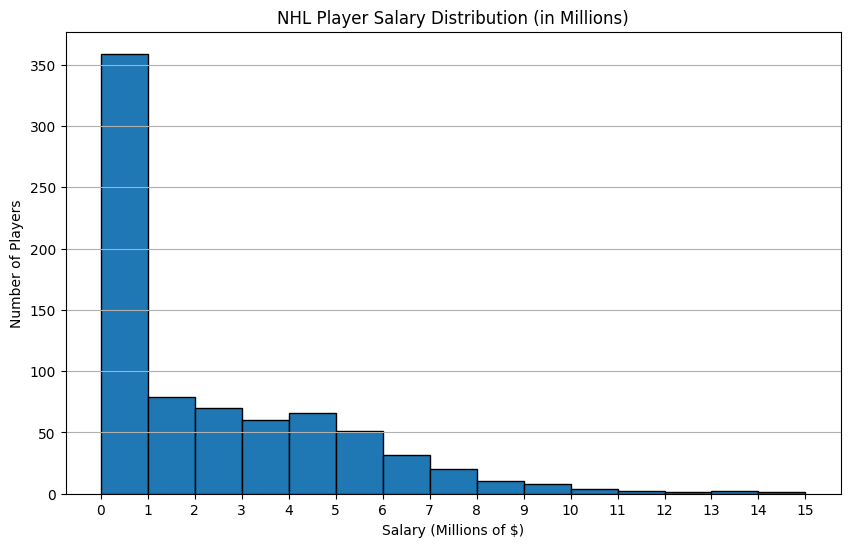

In [13]:
salaries_in_millions = df['Salary'] / 1_000_000

plt.figure(figsize=(10, 6))
plt.hist(salaries_in_millions, bins=range(0, int(salaries_in_millions.max()) + 2), edgecolor='black')
plt.title('NHL Player Salary Distribution (in Millions)')
plt.xlabel('Salary (Millions of $)')
plt.ylabel('Number of Players')
plt.xticks(range(0, int(salaries_in_millions.max()) + 2))
plt.grid(axis='y')
plt.show()

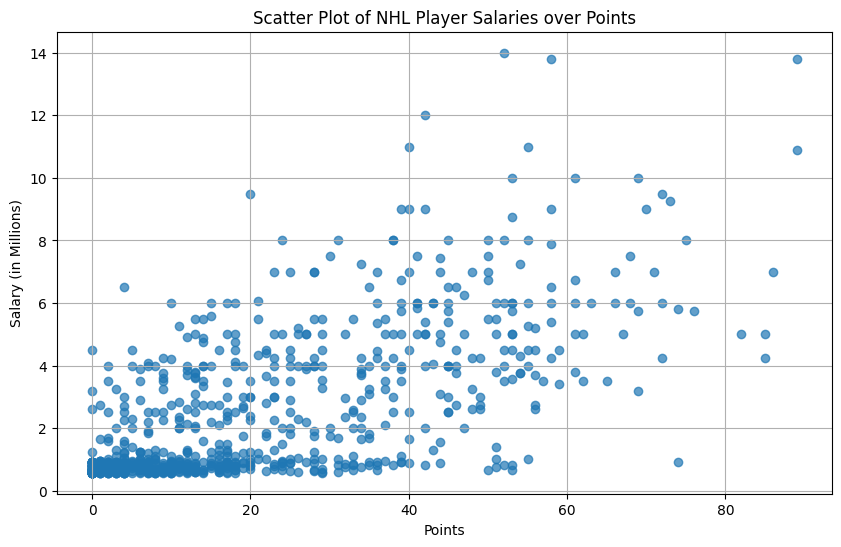

In [14]:
df_temp = df.copy()

df_temp['Salary_Millions'] = df_temp['Salary'] / 1_000_000

plt.figure(figsize=(10, 6))
plt.scatter(df_temp['PTS'], df_temp['Salary_Millions'], alpha=0.7)
plt.title('Scatter Plot of NHL Player Salaries over Points')
plt.xlabel('Points')
plt.ylabel('Salary (in Millions)')
plt.grid(True)
plt.show()

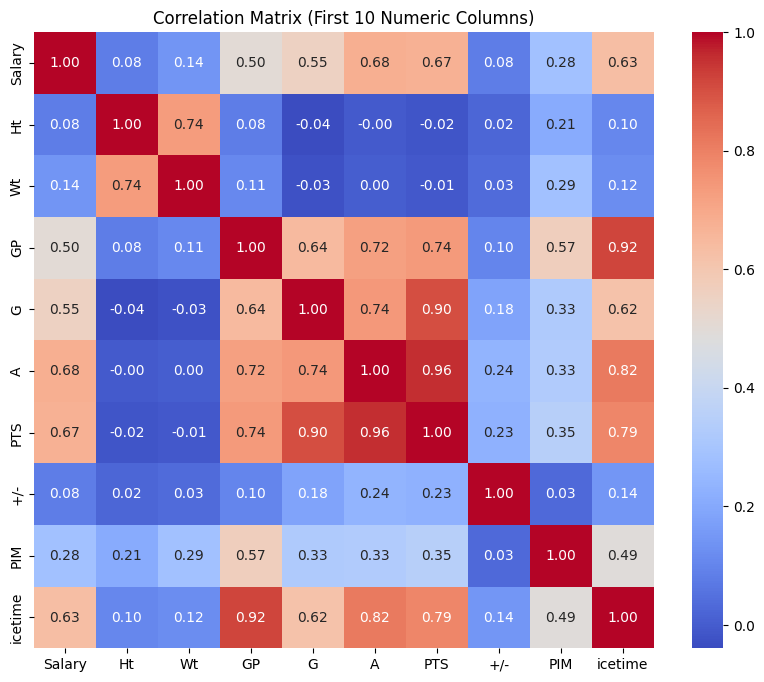

In [15]:
selected_columns = ['Salary', 'Ht', 'Wt', 'GP', 'G', 'A', 'PTS', '+/-', 'PIM', 'icetime']

df_10_cols = df[selected_columns]

corr_matrix = df_10_cols.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (First 10 Numeric Columns)')
plt.show()

**Further Cleaning and Preprocessing**

In [16]:
y = df['Salary']
X = df.drop(columns=['Salary', 'name', 'iceTimeRank', 'I_F_points', 'I_F_goals', 'penalties', 'I_F_penalityMinutes', 'penalityMinutes'])
#X = df.drop(columns=['Salary', 'name'])
#Apart from removing name and salary from X, the other six columns are removed due to being redundant.

In [17]:
print(X.columns.tolist())

['Ht', 'Wt', 'Hand', 'Position', 'GP', 'G', 'A', 'PTS', '+/-', 'PIM', 'icetime', 'shifts', 'gameScore', 'onIce_xGoalsPercentage', 'offIce_xGoalsPercentage', 'onIce_corsiPercentage', 'offIce_corsiPercentage', 'onIce_fenwickPercentage', 'offIce_fenwickPercentage', 'I_F_xOnGoal', 'I_F_xGoals', 'I_F_xRebounds', 'I_F_xFreeze', 'I_F_xPlayStopped', 'I_F_xPlayContinuedInZone', 'I_F_xPlayContinuedOutsideZone', 'I_F_flurryAdjustedxGoals', 'I_F_scoreVenueAdjustedxGoals', 'I_F_flurryScoreVenueAdjustedxGoals', 'I_F_primaryAssists', 'I_F_secondaryAssists', 'I_F_shotsOnGoal', 'I_F_missedShots', 'I_F_blockedShotAttempts', 'I_F_shotAttempts', 'I_F_rebounds', 'I_F_reboundGoals', 'I_F_freeze', 'I_F_playStopped', 'I_F_playContinuedInZone', 'I_F_playContinuedOutsideZone', 'I_F_savedShotsOnGoal', 'I_F_savedUnblockedShotAttempts', 'I_F_faceOffsWon', 'I_F_hits', 'I_F_takeaways', 'I_F_giveaways', 'I_F_lowDangerShots', 'I_F_mediumDangerShots', 'I_F_highDangerShots', 'I_F_lowDangerxGoals', 'I_F_mediumDangerxGoal

In [18]:
X.head()

,Ht,Wt,Hand,Position,GP,G,A,PTS,+/-,PIM,...,OnIce_A_xGoalsFromxReboundsOfShots,OnIce_A_xGoalsFromActualReboundsOfShots,OnIce_A_reboundxGoals,OnIce_A_xGoals_with_earned_rebounds,OnIce_A_xGoals_with_earned_rebounds_scoreAdjusted,OnIce_A_xGoals_with_earned_rebounds_scoreFlurryAdjusted,OffIce_F_xGoals,OffIce_A_xGoals,OffIce_F_shotAttempts,OffIce_A_shotAttempts
0,75,224,L,C,76,12,40,52,-10,28,...,10.49,11.74,11.74,69.95,70.56,69.02,130.06,121.13,2946,2530
1,71,177,L,RW/C,82,34,55,89,11,32,...,10.92,19.19,19.47,68.68,68.60,67.45,128.51,152.58,2692,3248
2,74,201,L,C,72,21,37,58,7,35,...,10.93,19.25,20.62,68.71,68.51,66.86,121.47,124.95,2581,2771
3,76,232,R,D,78,17,25,42,20,38,...,14.36,12.20,12.56,87.28,87.44,85.03,123.23,120.58,2708,2519
4,73,210,L,C/LW/RW,72,20,35,55,-1,10,...,13.63,16.31,16.86,82.05,82.58,80.63,112.16,139.90,2459,2959


In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = ['Hand', 'Position']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

preprocessor.fit(X_train)

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [21]:
#This is to check the pipeline worked as intended. The extra columns are from the one-hot columns
print("Original X_train shape:", X_train.shape)
print("Transformed X_train shape:", X_train_processed.shape)

Original X_train shape: (612, 145)
Transformed X_train shape: (612, 164)


**Linear and Regularized Regression Models**

Linear Regression: A foundational regression model that assumes a linear relationship between inputs and the target. This is our baseline model for understanding the relationship between our features and target.

In [22]:
Linear_Model = LinearRegression()
Linear_Model.fit(X_train_processed, y_train)
y_pred = Linear_Model.predict(X_test_processed)

li_mse = mean_squared_error(y_test, y_pred)
li_mae = mean_absolute_error(y_test, y_pred)
li_r2 = r2_score(y_test, y_pred)
li_rmse = np.sqrt(li_mse)

print(f"Mean Squared Error: {li_mse}")
print(f"Mean Absolute Error: {li_mae}")
print(f"R-squared: {li_r2}")
print(f"Root Mean Squared Error: {li_rmse}")

Mean Squared Error: 3876317421869.274
Mean Absolute Error: 1435764.5503930387
R-squared: 0.331858121100981
Root Mean Squared Error: 1968836.5655557278


Ridge Model: Similar to linear regression, but adds in L2 regularization to penalize large coefficients. This helps to reduce potential overfitting.

In [23]:
Ridge_Model = Ridge(alpha=1.0)
Ridge_Model.fit(X_train_processed, y_train)
y_pred = Ridge_Model.predict(X_test_processed)

rm_mse = mean_squared_error(y_test, y_pred)
rm_mae = mean_absolute_error(y_test, y_pred)
rm_r2 = r2_score(y_test, y_pred)
rm_rmse = np.sqrt(rm_mse)

print(f"Mean Squared Error: {rm_mse}")
print(f"Mean Absolute Error: {rm_mae}")
print(f"R-squared: {rm_r2}")
print(f"Root Mean Squared Error: {rm_rmse}")

Mean Squared Error: 2986411239163.225
Mean Absolute Error: 1264220.4215210183
R-squared: 0.48524689819198286
Root Mean Squared Error: 1728123.618021357


Lasso Regression: Like Ridge, but instead uses L1 regularization. This can shrink coefficients to zero and in doing so aids in regularization and feature selection.

In [24]:
Lasso_Model = Lasso(alpha= .01)
Lasso_Model.fit(X_train_processed, y_train)
y_pred = Lasso_Model.predict(X_test_processed)

la_mse = mean_squared_error(y_test, y_pred)
la_mae = mean_absolute_error(y_test, y_pred)
la_r2 = r2_score(y_test, y_pred)
la_rmse = np.sqrt(la_mse)

print(f"Mean Squared Error: {la_mse}")
print(f"Mean Absolute Error: {la_mae}")
print(f"R-squared: {la_r2}")
print(f"Root Mean Squared Error: {la_rmse}")

Mean Squared Error: 3281838633071.584
Mean Absolute Error: 1309842.2321530047
R-squared: 0.4343255229375834
Root Mean Squared Error: 1811584.5641513907


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.662e+14, tolerance: 3.415e+11
  model = cd_fast.enet_coordinate_descent(


Elastic Net: Combines the L1 and L2 mentioned above to help balance feature selection and coefficient shrinkage. Works well when numerous correlated features are present.

In [25]:
ElasticNet_Model = ElasticNet(alpha=0.1, l1_ratio=0.5)
ElasticNet_Model.fit(X_train_processed, y_train)
y_pred = ElasticNet_Model.predict(X_test_processed)

en_mse = mean_squared_error(y_test, y_pred)
en_mae = mean_absolute_error(y_test, y_pred)
en_r2 = r2_score(y_test, y_pred)
en_rmse = np.sqrt(en_mse)

print(f"Mean Squared Error: {en_mse}")
print(f"Mean Absolute Error: {en_mae}")
print(f"R-squared: {en_r2}")
print(f"Root Mean Squared Error: {en_rmse}")

Mean Squared Error: 2605387172204.363
Mean Absolute Error: 1175332.2035383293
R-squared: 0.5509221534142126
Root Mean Squared Error: 1614121.1764314235


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.205e+14, tolerance: 3.415e+11
  model = cd_fast.enet_coordinate_descent(


Stochastic Gradient Descent (SGD): A version of linear regressing where weights are updated incrementally.

In [26]:
sgd_Model = SGDRegressor(
    max_iter=1000,
    early_stopping=True,
    penalty='l2',
    learning_rate='invscaling',
    eta0=0.01,
    validation_fraction=0.25,
    n_iter_no_change=3,
    random_state=42
)

sgd_Model.fit(X_train_processed, y_train)
y_pred = sgd_Model.predict(X_test_processed)

sgd_mse = mean_squared_error(y_test, y_pred)
sgd_mae = mean_absolute_error(y_test, y_pred)
sgd_r2 = r2_score(y_test, y_pred)
sgd_rmse = np.sqrt(sgd_mse)

print(f"Mean Squared Error: {sgd_mse}")
print(f"Mean Absolute Error: {sgd_mae}")
print(f"R-squared: {sgd_r2}")
print(f"Root Mean Squared Error: {sgd_rmse}")

Mean Squared Error: 3043194983759.03
Mean Absolute Error: 1362927.234584005
R-squared: 0.4754593618072903
Root Mean Squared Error: 1744475.5612386863


**Hyperparameter-Tuned Models**

Grid Search Ridge: Ridge regressing where regularization is determined using GridSearchCV, allowing for systematic hyperparameter tuning.

In [27]:
param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}

ridge = Ridge()
grid_search = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_root_mean_squared_error')
grid_search.fit(X_train_processed, y_train)

print("Best alpha:", grid_search.best_params_)
print("Best RMSE (CV):", -grid_search.best_score_)

grid_ridge = grid_search.best_estimator_
y_pred = grid_ridge.predict(X_test_processed)

gr_mse = mean_squared_error(y_test, y_pred)
gr_mae = mean_absolute_error(y_test, y_pred)
gr_r2 = r2_score(y_test, y_pred)
gr_rmse = np.sqrt(gr_mse)

print(f"Mean Squared Error: {gr_mse}")
print(f"Mean Absolute Error: {gr_mae}")
print(f"R-squared: {gr_r2}")
print(f"Root Mean Squared Error: {gr_rmse}")

Best alpha: {'alpha': 10}
Best RMSE (CV): 1566508.2699131425
Mean Squared Error: 2708957003545.1455
Mean Absolute Error: 1210159.4272575958
R-squared: 0.5330703280402432
Root Mean Squared Error: 1645890.9452163426


**Ensemble and Tree-Based Models**

Random Forest: An ensemble of decision trees using bootstrapped data with random feature selection. Robust to the problem of overfitting.

In [28]:
RF_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

RF_model.fit(X_train_processed, y_train)

y_pred = RF_model.predict(X_test_processed)

rf_mse = mean_squared_error(y_test, y_pred)
rf_mae = mean_absolute_error(y_test, y_pred)
rf_r2 = r2_score(y_test, y_pred)
rf_rmse = np.sqrt(rf_mse)

print(f"Mean Squared Error: {rf_mse}")
print(f"Mean Absolute Error: {rf_mae}")
print(f"R-squared: {rf_r2}")
print(f"Root Mean Squared Error: {rf_rmse}")

Mean Squared Error: 2506277360026.718
Mean Absolute Error: 1131498.720640523
R-squared: 0.5680052270944294
Root Mean Squared Error: 1583122.661080536


XGBoost: A gradient booting method that builds trees in order to correct errors from prior iterations.

In [29]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_processed, y_train)

y_pred = xgb_model.predict(X_test_processed)

xgb_mse = mean_squared_error(y_test, y_pred)
xgb_mae = mean_absolute_error(y_test, y_pred)
xgb_r2 = r2_score(y_test, y_pred)
xgb_rmse = np.sqrt(xgb_mse)

print(f"Mean Squared Error: {xgb_mse}")
print(f"Mean Absolute Error: {xgb_mae}")
print(f"R-squared: {xgb_r2}")
print(f"Root Mean Squared Error: {xgb_rmse}")

Mean Squared Error: 2580477902848.0
Mean Absolute Error: 1151670.375
R-squared: 0.55521559715271
Root Mean Squared Error: 1606386.5981911079


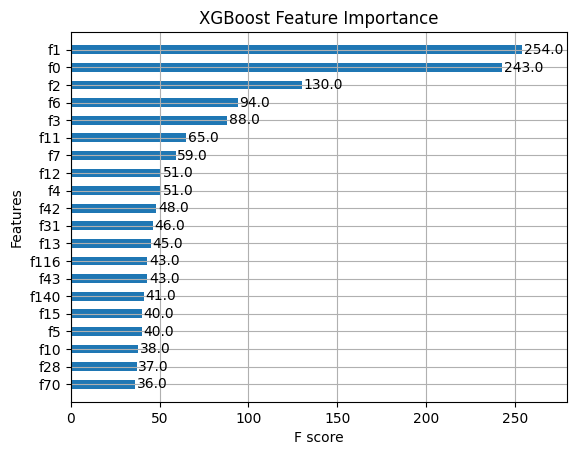

In [30]:
plot_importance(xgb_model, max_num_features=20, height=0.5)
plt.title("XGBoost Feature Importance")
plt.show()

In [31]:
#feature_names = preprocessor.get_feature_names_out()
#print(f"Feature at f3: {feature_names[3]}")

LightGBM: A gradient boosting method that is known for speed and efficiency. Works well with large data sets that have a high degree of dimensionality.

In [32]:
lgb_model = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

lgb_model.fit(X_train_processed, y_train)

y_pred = lgb_model.predict(X_test_processed)

lgb_mse = mean_squared_error(y_test, y_pred)
lgb_mae = mean_absolute_error(y_test, y_pred)
lgb_r2 = r2_score(y_test, y_pred)
lgb_rmse = np.sqrt(lgb_mse)

print(f"Mean Squared Error: {lgb_mse}")
print(f"Mean Absolute Error: {lgb_mae}")
print(f"R-squared: {lgb_r2}")
print(f"Root Mean Squared Error: {lgb_rmse}")

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003275 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20239
[LightGBM] [Info] Number of data points in the train set: 612, number of used features: 153
[LightGBM] [Info] Start training from score 2472301.730392
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


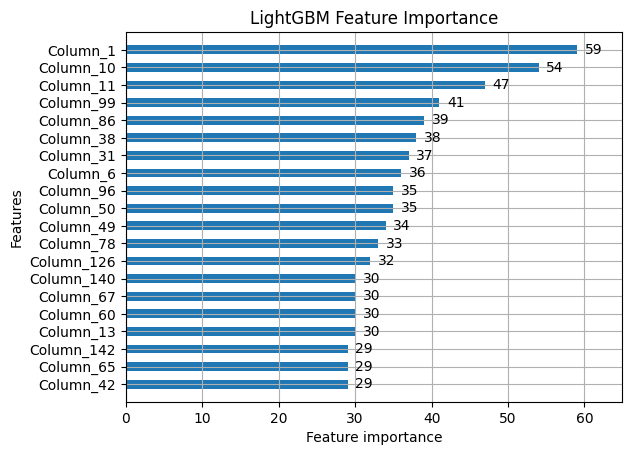

In [33]:
lgb.plot_importance(lgb_model, max_num_features=20, height=0.5)
plt.title("LightGBM Feature Importance")
plt.show()

**Neural Network**

MLP Regressor: A feed forward neural network that learns complex, non-linear relationships between inputs and targets by optimizing weights through backpropagation.

In [34]:
nn_model = MLPRegressor(
    hidden_layer_sizes=(128, 128, 64),
    activation='relu',
    solver='adam',
    max_iter=1000,
    alpha=0.0001,
    learning_rate='adaptive',
    random_state=42
)

nn_model.fit(X_train_processed, y_train)

y_pred = nn_model.predict(X_test_processed)

nn_mse = mean_squared_error(y_test, y_pred)
nn_mae = mean_absolute_error(y_test, y_pred)
nn_r2 = r2_score(y_test, y_pred)
nn_rmse = np.sqrt(nn_mse)

print(f"Mean Squared Error: {nn_mse}")
print(f"Mean Absolute Error: {nn_mae}")
print(f"R-squared: {nn_r2}")
print(f"Root Mean Squared Error: {nn_rmse}")

Mean Squared Error: 3081420013322.786
Mean Absolute Error: 1158401.13200013
R-squared: 0.4688707003809558
Root Mean Squared Error: 1755397.3947009225


**Results, Evaluation, Conclusions**

**Evaluation Metrics:**
- Mean Squared Error (MSE): Measures the average of the squared differences between predicted and actual values. Puts added emphasis on larger errors and is sensitive to outliers.
- Mean Absolute Error (MAE): Measures the average absolute difference between predicted and actual values. Creates an easier to interpret metric.
- R-Squared: Indicates the proportion of variance in the target variable that is explained by the model. A value of one would mean the model explains all variance, while zero would inidcate no explanation.
- Root Mean Squared Error (RMSE): Measures the square root of the average squared differences between predicted and actual values. Penalizes larger errors more.

In [35]:
results_df = pd.DataFrame([
    {"Model": "Linear", "MSE": li_mse, "MAE": li_mae, "R2": li_r2, "RMSE": li_rmse},
    {"Model": "Ridge", "MSE": rm_mse, "MAE": rm_mae, "R2": rm_r2, "RMSE": rm_rmse},
    {"Model": "Lasso", "MSE": la_mse, "MAE": la_mae, "R2": la_r2, "RMSE": la_rmse},
    {"Model": "ElasticNet", "MSE": en_mse, "MAE": en_mae, "R2": en_r2, "RMSE": en_rmse},
    {"Model": "SGD", "MSE": sgd_mse, "MAE": sgd_mae, "R2": sgd_r2, "RMSE": sgd_rmse},
    {"Model": "Grid Ridge", "MSE": gr_mse, "MAE": gr_mae, "R2": gr_r2, "RMSE": gr_rmse},
    {"Model": "Random Forest", "MSE": rf_mse, "MAE": rf_mae, "R2": rf_r2, "RMSE": rf_rmse},
    {"Model": "XGBoost", "MSE": xgb_mse, "MAE": xgb_mae, "R2": xgb_r2, "RMSE": xgb_rmse},
    {"Model": "LightGBM", "MSE": lgb_mse, "MAE": lgb_mae, "R2": lgb_r2, "RMSE": lgb_rmse},
    {"Model": "Neural Network", "MSE": nn_mse, "MAE": nn_mae, "R2": nn_r2, "RMSE": nn_rmse}

])

results_df.sort_values(by="RMSE", ascending=True, inplace=True)
rounded_df = results_df.copy()
scale_factor = 1e6

print(tabulate(rounded_df, headers='keys', tablefmt='grid'))

+----+----------------+-------------+-------------+----------+-------------+
|    | Model          |         MSE |         MAE |       R2 |        RMSE |
+====+================+=============+=============+==========+=============+
|  6 | Random Forest  | 2.50628e+12 | 1.1315e+06  | 0.568005 | 1.58312e+06 |
+----+----------------+-------------+-------------+----------+-------------+
|  7 | XGBoost        | 2.58048e+12 | 1.15167e+06 | 0.555216 | 1.60639e+06 |
+----+----------------+-------------+-------------+----------+-------------+
|  3 | ElasticNet     | 2.60539e+12 | 1.17533e+06 | 0.550922 | 1.61412e+06 |
+----+----------------+-------------+-------------+----------+-------------+
|  5 | Grid Ridge     | 2.70896e+12 | 1.21016e+06 | 0.53307  | 1.64589e+06 |
+----+----------------+-------------+-------------+----------+-------------+
|  1 | Ridge          | 2.98641e+12 | 1.26422e+06 | 0.485247 | 1.72812e+06 |
+----+----------------+-------------+-------------+----------+-------------+

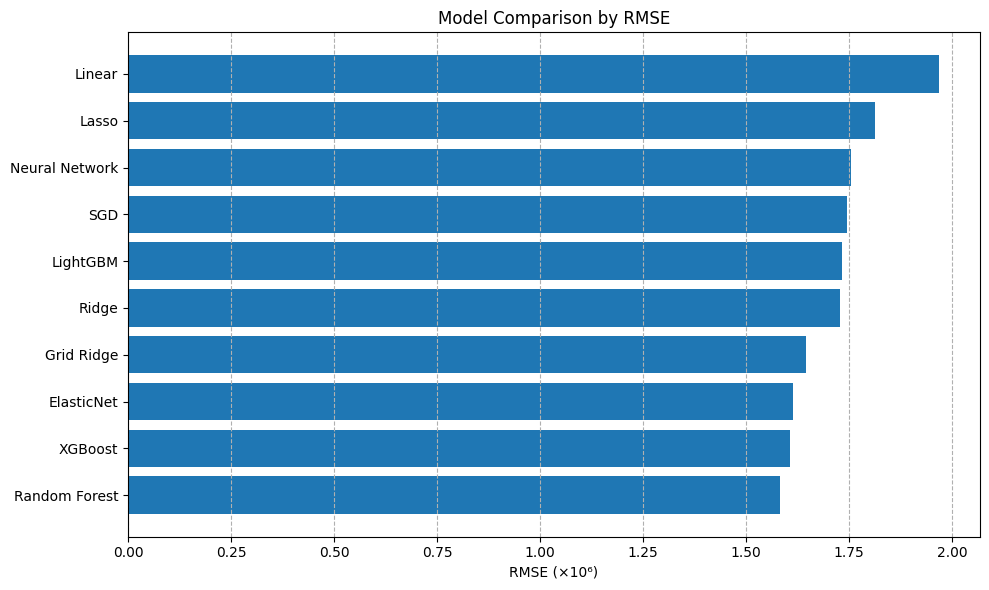

In [36]:

rounded_df_plot = results_df.copy()
rounded_df_plot.sort_values("RMSE", inplace=True)

plt.figure(figsize=(10, 6))
plt.barh(rounded_df_plot["Model"], rounded_df_plot["RMSE"] / 1e6)
plt.xlabel("RMSE (×10⁶)")
plt.title("Model Comparison by RMSE")
plt.grid(True, axis='x', linestyle='--')
plt.tight_layout()
plt.show()

**Model Evaluation and Testing:**

To evaluate the best-performing model, we tested it on five players who signed contracts during the 2024–2025 NHL season. The input data used came from each player's 2023–2024 statistics, as most contracts were finalized before the current season ended. While the original salary data came from Kaggle, updated contract figures were gathered via Google searches, and statistical data continued to be sourced from MoneyPuck.

Because of the time gap between the training data and the current test data, we applied a salary cap inflation adjustment. The NHL salary cap rose from 73 million USD in 2016–2017 to 88 million USD in 2024–2025. A multiplier of 1.204 was used to account for this increase and to make the predicted salaries more comparable to present-day figures.

In [37]:
df3 = pd.read_csv("2023_2024_stats.csv")
df4 = pd.read_csv("Test_Salaries.csv")

In [38]:
df4.head()

,Salary,Ht,Wt,Hand,Last Name,First Name,Position,GP,G,A,PTS,+/-,PIM
0,4750000,71,195,R,Palmieri,Kyle,RW,82,30,24,54,-16,26
1,7000000,72,190,R,Pionk,Neal,D,82,5,28,33,9,63
2,9000000,74,216,L,Chychrun,Jakob,D,82,14,27,41,-30,60
3,12000000,76,216,L,Rantanen,Mikko,RW/C,82,42,62,104,19,50
4,7450000,74,196,L,Lafrenire,Alexis,LW,82,28,29,57,2,40


In [39]:
df4['name'] = df4['First Name'] + ' ' + df4['Last Name']
df4 = df4.drop(columns=['First Name', 'Last Name'])

In [40]:
dft = pd.merge(df4, df3, on='name', how='inner')

In [41]:
dft.head()

,Salary,Ht,Wt,Hand,Position,GP,G,A,PTS,+/-,...,OnIce_A_xGoalsFromxReboundsOfShots,OnIce_A_xGoalsFromActualReboundsOfShots,OnIce_A_reboundxGoals,OnIce_A_xGoals_with_earned_rebounds,OnIce_A_xGoals_with_earned_rebounds_scoreAdjusted,OnIce_A_xGoals_with_earned_rebounds_scoreFlurryAdjusted,OffIce_F_xGoals,OffIce_A_xGoals,OffIce_F_shotAttempts,OffIce_A_shotAttempts
0,4750000,71,195,R,RW,82,30,24,54,-16,...,10.42,17.74,18.39,72.66,72.37,70.49,147.40,184.09,3173,4065
1,7000000,72,190,R,D,82,5,28,33,9,...,14.36,27.62,27.62,82.49,82.41,79.75,167.58,147.06,3275,3099
2,9000000,74,216,L,D,82,14,27,41,-30,...,11.81,19.32,19.32,75.97,76.75,75.39,152.19,163.07,3095,3182
3,12000000,76,216,L,RW/C,82,42,62,104,19,...,11.58,19.47,19.47,79.25,79.13,77.08,135.62,170.82,2750,3137
4,7450000,74,196,L,LW,82,28,29,57,2,...,9.05,16.46,16.46,64.03,64.19,63.31,185.07,178.49,3423,3653


In [42]:
player_names = dft['name']
actual_salary= dft['Salary']
X2 = dft.drop(columns=['Salary', 'name', 'iceTimeRank', 'I_F_points', 'I_F_goals', 'penalties', 'I_F_penalityMinutes', 'penalityMinutes'])
#X2 = dft.drop(columns=['Salary', 'name'])
#X2 = X2.iloc[:, :19]

In [43]:
X_2_processed = preprocessor.transform(X2)

In [44]:
predicted_salaries = RF_model.predict(X_2_processed)

In [45]:
results = pd.DataFrame({
    "Player": player_names,
    "Predicted Salary": predicted_salaries,
    "Actual Salary": dft["Salary"] if "Salary" in dft.columns else None
})

In [46]:
results["Predicted Salary Raw"] = results["Predicted Salary"].replace('[\$,]', '', regex=True).astype(float)

# Calculate adjusted salary (predicted × 1.204)
results["Adjusted Salary Raw"] = results["Predicted Salary Raw"] * 1.204

# Format both predicted and adjusted salaries as strings with $ and commas
results["Predicted Salary"] = results["Predicted Salary Raw"].apply(lambda x: f"${x:,.0f}")
results["Adjusted Salary"] = results["Adjusted Salary Raw"].apply(lambda x: f"${x:,.0f}")

if "Salary" in dft.columns:
    results["Actual Salary"] = dft["Salary"].astype(float)
    results["Actual Salary"] = results["Actual Salary"].apply(lambda x: f"${x:,.0f}")

final_results = results[["Player", "Actual Salary", "Predicted Salary", "Adjusted Salary"]]

print(tabulate(final_results, headers='keys', tablefmt='grid', showindex= False))

+------------------+-----------------+--------------------+-------------------+
| Player           | Actual Salary   | Predicted Salary   | Adjusted Salary   |
+==================+=================+====================+===================+
| Kyle Palmieri    | $4,750,000      | $5,676,345         | $6,834,319        |
+------------------+-----------------+--------------------+-------------------+
| Neal Pionk       | $7,000,000      | $4,008,275         | $4,825,963        |
+------------------+-----------------+--------------------+-------------------+
| Jakob Chychrun   | $9,000,000      | $5,425,260         | $6,532,013        |
+------------------+-----------------+--------------------+-------------------+
| Mikko Rantanen   | $12,000,000     | $8,813,295         | $10,611,207       |
+------------------+-----------------+--------------------+-------------------+
| Alexis Lafrenire | $7,450,000      | $5,841,120         | $7,032,708        |
+------------------+-----------------+--

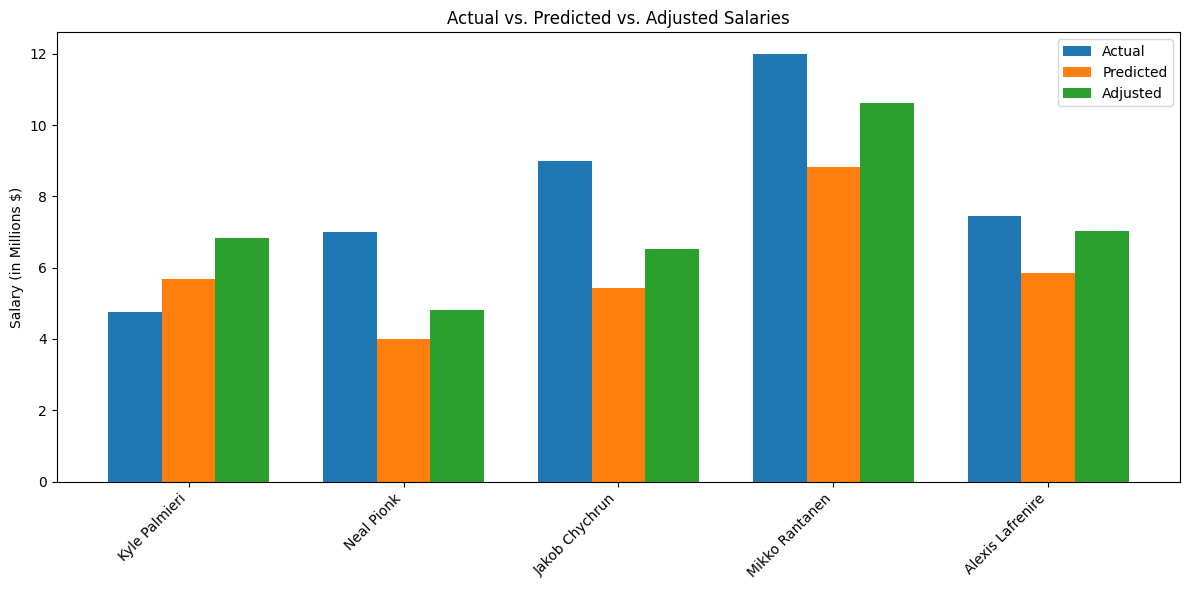

In [47]:
# Convert values to millions
actual = results["Actual Salary"].replace('[\$,]', '', regex=True).astype(float) / 1e6
predicted = results["Predicted Salary Raw"] / 1e6
adjusted = results["Adjusted Salary Raw"] / 1e6
players = results["Player"]

x = np.arange(len(players))
width = 0.25

plt.figure(figsize=(12, 6))
plt.bar(x - width, actual, width, label='Actual')
plt.bar(x, predicted, width, label='Predicted')
plt.bar(x + width, adjusted, width, label='Adjusted')

plt.xticks(x, players, rotation=45, ha='right')
plt.ylabel('Salary (in Millions $)')
plt.title('Actual vs. Predicted vs. Adjusted Salaries')
plt.legend()
plt.tight_layout()
plt.show()

**Model Limitations and Observations:**

While none of the models demonstrated high accuracy, they serve as a useful starting point in estimating a player’s value. Various factors can influence a player’s salary—some measurable, others not. Quantifiable features that could improve future models include player age and contract length. For instance, older players may prefer short-term, high-value deals, whereas younger players might opt for longer-term contracts that spread earnings over multiple years.

Another quantifiable factor is geographic location. State income tax can significantly influence contract decisions, with players in low- or no-tax states (e.g., Florida) potentially accepting lower average annual values. On the qualitative side, traits like leadership and toughness—while difficult to measure—often influence contract negotiations. Additionally, public perception and media narratives can shape contract outcomes. “Hometown discounts” or media-driven speculation may drive salaries away from purely data-driven valuations.

Such human factors can explain why machine learning models struggle with precise salary prediction. Human decision-making is not always logical or linear—emotions, perceptions, and external narratives frequently intervene—limiting the predictive power of data-only approaches.

**Recommendations for Future Work:**

Future versions of this project could incorporate more contextual variables such as player age, contract term, and signing location. Additionally, models should focus on evaluating players at the point of contract signing rather than using arbitrary future dates. The original model’s training data spans several years, which introduces inconsistencies given the evolving salary cap and economic environment. A more accurate approach would align player statistics and contract values based on the season in which the contract was signed.

Historical performance should also be emphasized. Since teams typically base contracts on past performance, using a player’s statistics from the prior two or three seasons may offer better predictive insights than current-season data alone. Finally, future iterations should adapt to shifts in the player market and broader economic conditions affecting professional sports franchises.

**Broader Implications**

While this project focuses on hockey and the economics of professional sports, its methods have much broader applicability. Similar models could be used to estimate compensation in other industries, provided appropriate data is available. The same modeling principles apply to housing price prediction (beyond square footage and bedroom count), risk assessments, sales forecasting, and medical research, among others. Any multivariate problem that extends beyond simple binary classification could potentially be addressed using models like those developed in this project.

**Resources:**

MoneyPuck. (n.d.). Download Player and Team Data. Retrieved June 13, 2025, from https://moneypuck.com/data.htm

Klassen, B. (n.d.). Regularization, Kernel Smoothing, Tree Methods [Code notebook]. Kaggle. Retrieved June 13, 2025, from https://www.kaggle.com/code/bradklassen/regularization-kernel-smoothing-tree-methods/notebook